# PhishGuard — Model Comparison & Explainability Evaluation
### Phase 8: Final Model Evaluation, Confusion Matrices, and SHAP Visualizations

**Objective**:
Compare performance across all three evaluated architectures (**Logistic Regression**, **Random Forest**, and **XGBoost**) on the held-out test set (1,500 URLs).
Generate publication-quality figures:
1. Multi-model confusion matrix comparison side-by-side (`evaluation/confusion_matrices_combined.png`)
2. Global TreeSHAP feature importance summary plot (`evaluation/shap_summary_plot.png`)
3. Individual local SHAP waterfall / horizontal contribution plots for representative URLs (`evaluation/shap_waterfall_*.png`)
4. Markdown-formatted comparison table for inclusion in the final report.


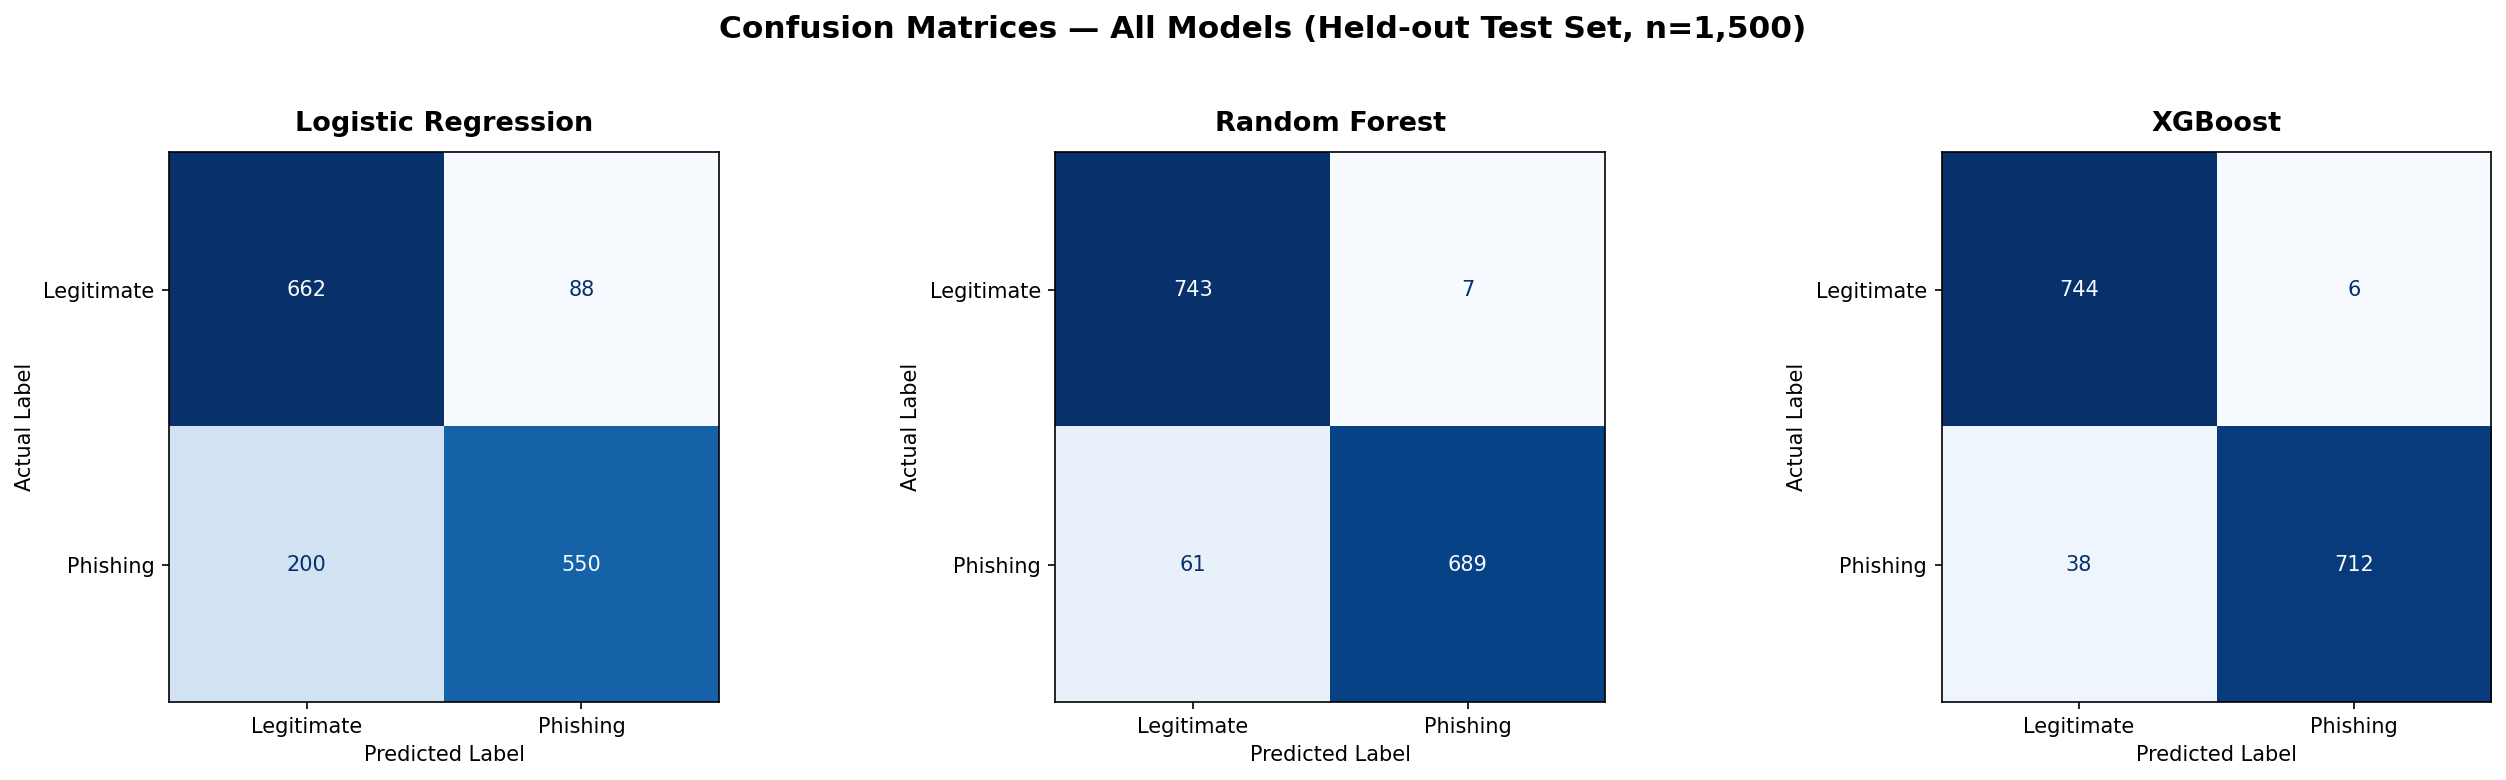

In [1]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import sys

sys.path.insert(0, str(Path("..").resolve()))
from src.features import FEATURE_NAMES

test_df = pd.read_csv("../data/processed/test.csv")
X_test = test_df[FEATURE_NAMES].values
y_test = test_df["label"].values

models_info = [
    ("Logistic Regression", "logistic_regression"),
    ("Random Forest", "random_forest"),
    ("XGBoost", "xgboost"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=150)
for ax, (name, fname) in zip(axes, models_info):
    model = joblib.load(f"../models/{fname}.joblib")
    cm = confusion_matrix(y_test, model.predict(X_test))
    disp = ConfusionMatrixDisplay(cm, display_labels=["Legitimate", "Phishing"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(name, fontsize=13, fontweight="bold", pad=10)
    ax.set_xlabel("Predicted Label", fontweight="medium")
    ax.set_ylabel("Actual Label", fontweight="medium")

plt.suptitle("Confusion Matrices — All Models (Held-out Test Set, n=1,500)", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig("../evaluation/confusion_matrices_combined.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Global SHAP Feature Importance Summary
Generating global TreeSHAP summary plot across a representative sample of 200 training instances.
Features are ranked by mean absolute SHAP value, with color representing feature value (red = high, blue = low).


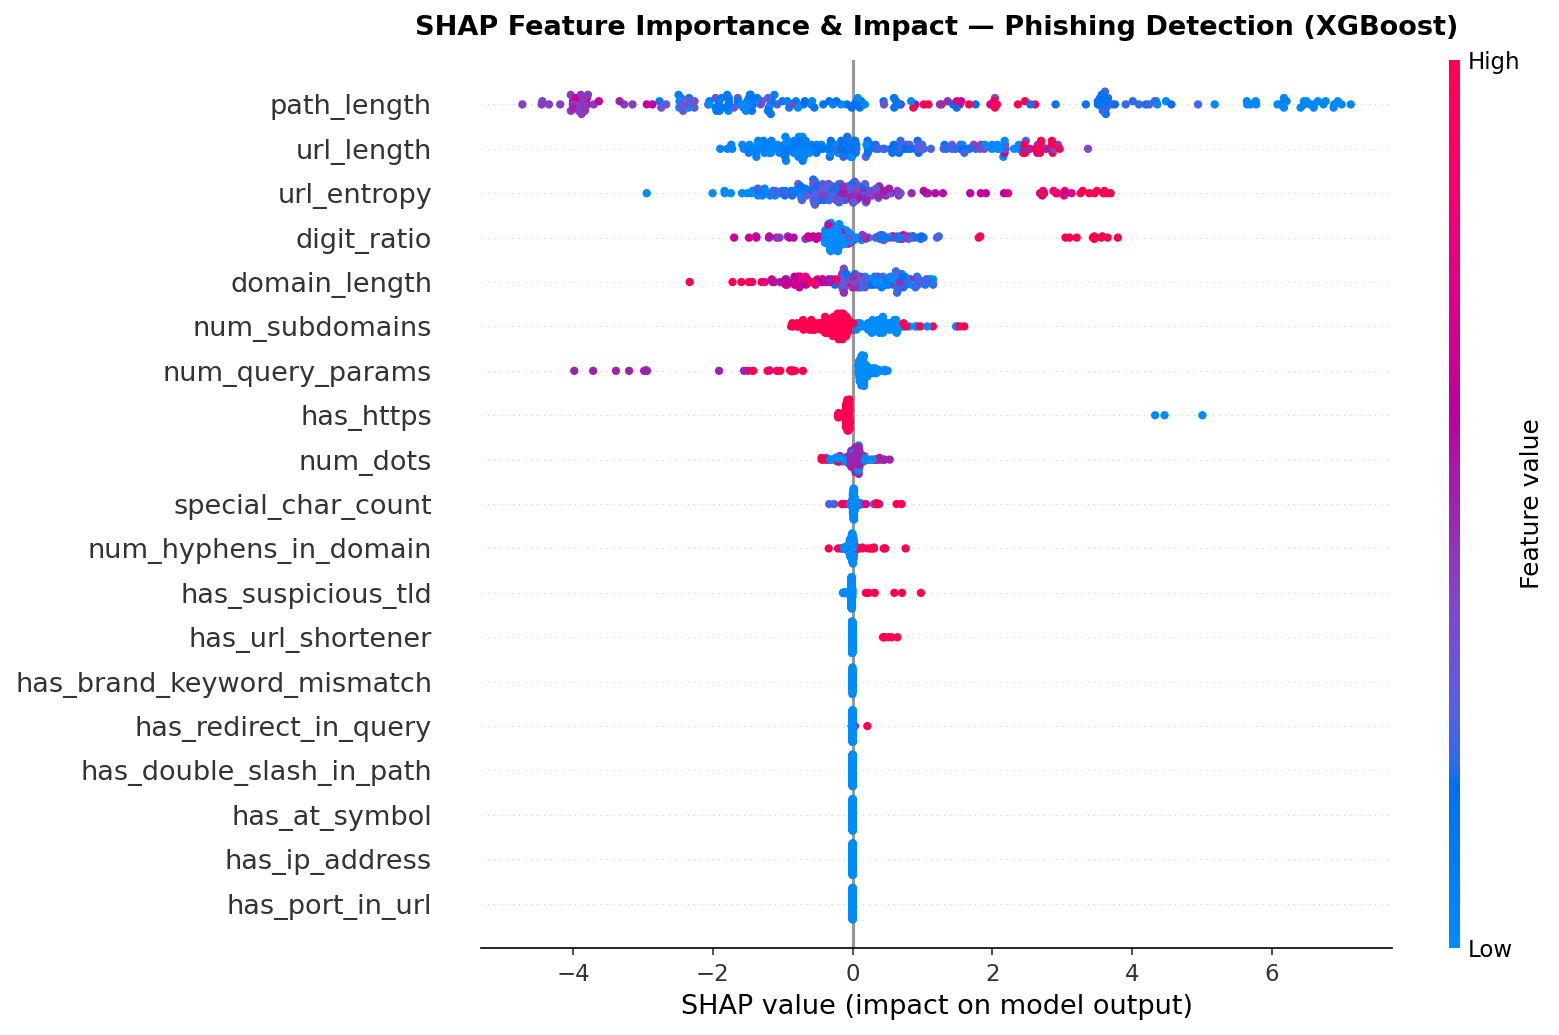

In [2]:
import shap

best_model = joblib.load("../models/best_model.joblib")
train_df = pd.read_csv("../data/processed/train.csv")
X_train = train_df[FEATURE_NAMES].values[:200]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_train)
values = shap_values[1] if isinstance(shap_values, list) else shap_values

plt.figure(figsize=(11, 7), dpi=150)
shap.summary_plot(values, X_train, feature_names=FEATURE_NAMES, show=False, plot_size=(11, 7))
plt.title("SHAP Feature Importance & Impact — Phishing Detection (XGBoost)", fontsize=13, fontweight="bold", pad=12)
plt.tight_layout()
plt.savefig("../evaluation/shap_summary_plot.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Local SHAP Risk Contribution Waterfall Plots
Visualizing individual decision breakdowns for 3 qualitative URL archetypes:
1. **Obvious Phishing**: Free TLD (`.tk`), brand impersonation (`paypal-secure-login`), missing HTTPS.
2. **Obvious Legitimate**: Clean apex developer site (`github.com`) with valid HTTPS.
3. **Borderline Impersonation**: Legitimate brand token (`paypal.com`) placed in subdomain of third-party registrar.


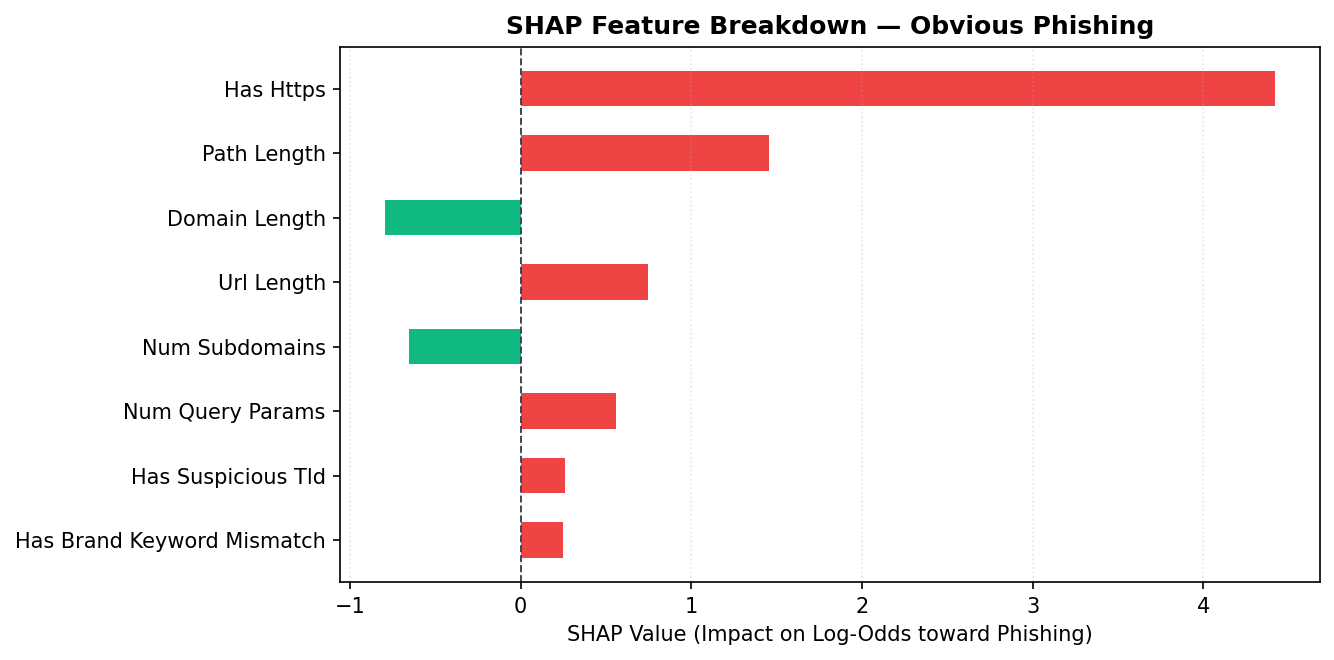

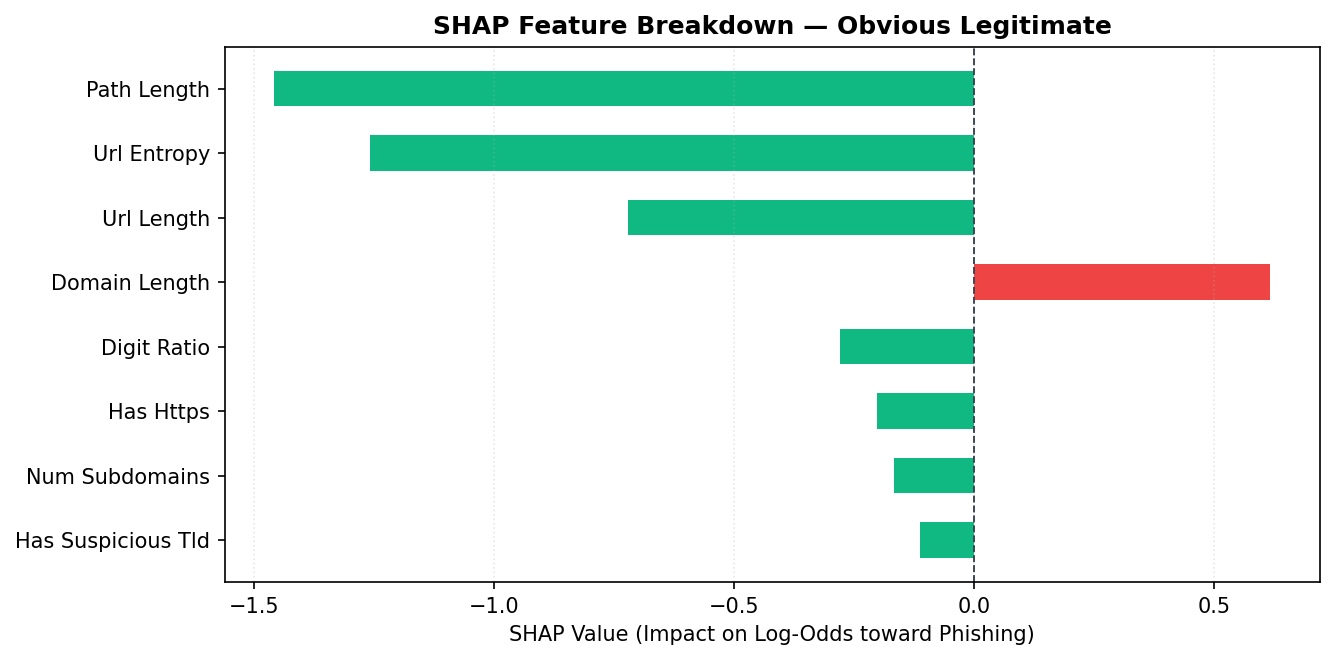

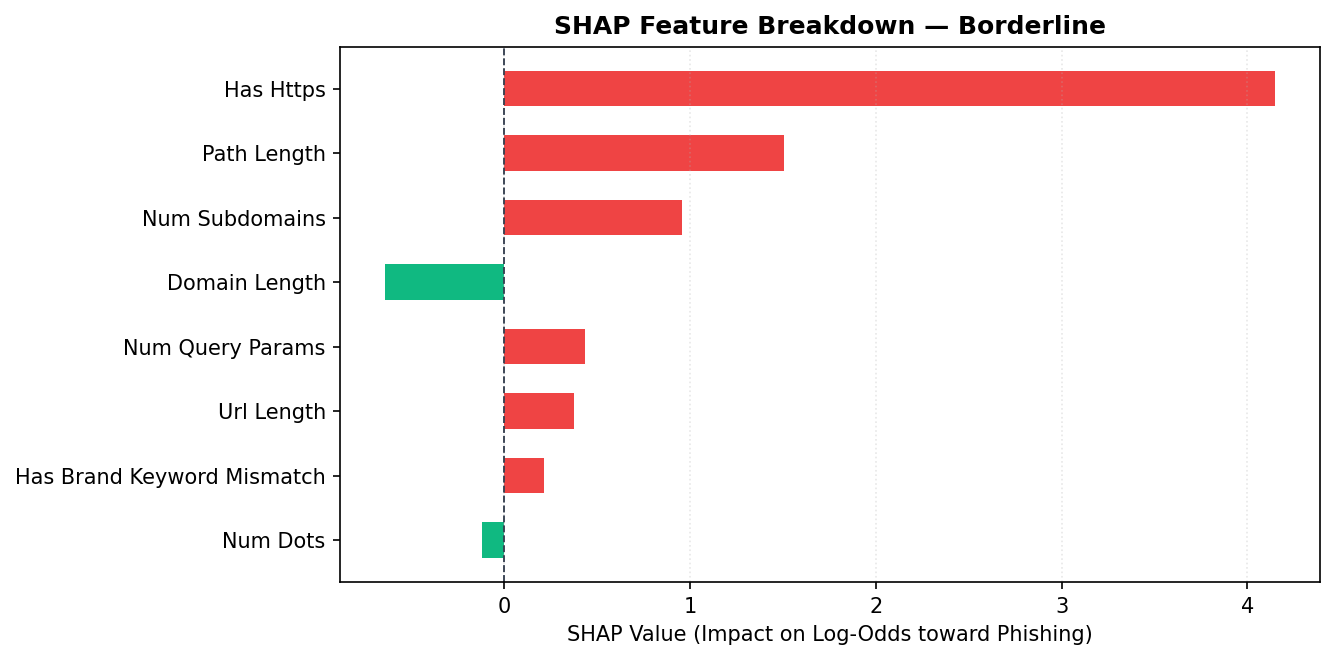

In [3]:
from src.features import extract_features

example_urls = {
    "obvious_phishing":  "http://paypal-secure-login.verify-account.tk/signin",
    "obvious_legitimate": "https://www.github.com",
    "borderline":         "http://paypal.com.secure-login.net/verify",
}

for label, url in example_urls.items():
    features = extract_features(url)
    X = np.array([[features.get(f, 0) for f in FEATURE_NAMES]])
    sv = explainer.shap_values(X)
    values_1url = sv[1][0] if isinstance(sv, list) else sv[0]

    pairs = sorted(zip(FEATURE_NAMES, values_1url), key=lambda x: abs(x[1]), reverse=True)[:8]
    names = [p[0].replace("_", " ").title() for p in pairs]
    vals = [p[1] for p in pairs]
    colors = ["#ef4444" if v > 0 else "#10b981" for v in vals]

    fig, ax = plt.subplots(figsize=(9, 4.5), dpi=150)
    ax.barh(names[::-1], vals[::-1], color=colors[::-1], height=0.55)
    ax.axvline(0, color="#374151", linewidth=0.9, linestyle="--")
    ax.set_title(f"SHAP Feature Breakdown — {label.replace('_', ' ').title()}", fontweight="bold", fontsize=12)
    ax.set_xlabel("SHAP Value (Impact on Log-Odds toward Phishing)", fontsize=10)
    ax.grid(axis="x", alpha=0.3, linestyle=":")
    plt.tight_layout()
    plt.savefig(f"../evaluation/shap_waterfall_{label}.png", dpi=150, bbox_inches="tight")
    plt.show()


## 4. Final Quantitative Model Comparison Table
Final test metrics across all three architectures, formatted in Markdown for direct report inclusion.


In [4]:
metrics_df = pd.read_csv("../evaluation/metrics_summary.csv")
test_only = metrics_df[metrics_df["split"] == "test"].copy()

for col in ["accuracy", "precision_macro", "recall_macro", "f1_macro", "auc", "false_negative_rate"]:
    if col in test_only.columns:
        test_only[col] = test_only[col].round(4)

print("=" * 70)
print("FINAL METRICS COMPARISON TABLE (TEST SET)")
print("=" * 70)
markdown_table = test_only[["model", "accuracy", "precision_macro", "recall_macro",
                            "f1_macro", "auc", "false_negative_rate"]].to_markdown(index=False)
print(markdown_table)
print("=" * 70)


FINAL METRICS COMPARISON TABLE (TEST SET)


| model               |   accuracy |   precision_macro |   recall_macro |   f1_macro |    auc |   false_negative_rate |
|:--------------------|-----------:|------------------:|---------------:|-----------:|-------:|----------------------:|
| Logistic Regression |     0.808  |            0.815  |         0.808  |     0.8069 | 0.8742 |                0.2667 |
| Random Forest       |     0.9547 |            0.957  |         0.9547 |     0.9546 | 0.9879 |                0.0813 |
| XGBoost             |     0.9707 |            0.9715 |         0.9707 |     0.9707 | 0.9916 |                0.0507 |
